# Advanced Machine Learning — Lab 4
## Continual (Incremental) Learning: Catastrophic Forgetting, EWC, and Replay

**Full name :** Djouaher Yasmine

**Group :** SID1

> **Duration:** 2 hours | **Framework:** TensorFlow / Keras | **Dataset:** Split MNIST

---

###  Objectives
By the end of this lab you will be able to:
- Demonstrate **catastrophic forgetting** on a sequential benchmark
- Build a **Split MNIST** continual learning benchmark
- Implement and evaluate **Experience Replay**
- Implement and evaluate **EWC (Elastic Weight Consolidation)**
- Compare methods using **accuracy matrices** and **forgetting metrics**

---

###  Key formulas

**Accuracy matrix** — $A_{i,j}$ = accuracy on task $j$ right after training task $i$

**Forgetting** — $F_j = \max_{i \le K} A_{i,j} - A_{K,j}$

**EWC loss** — $\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(\theta) + \dfrac{\lambda}{2}\sum_k F_k(\theta_k - \theta_k^{\text{old}})^2$


## Part 0 — Setup & Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.19.0


## Part 1 — Split MNIST Benchmark

We split MNIST into 5 sequential **binary** tasks:
| Task | Digits |
|------|--------|
| T1   | 0 vs 1 |
| T2   | 2 vs 3 |
| T3   | 4 vs 5 |
| T4   | 6 vs 7 |
| T5   | 8 vs 9 |


In [2]:
# Load and preprocess MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train_full = (x_train_full.astype('float32') / 255.0).reshape(-1, 784)
x_test_full  = (x_test_full.astype('float32')  / 255.0).reshape(-1, 784)

TASKS = [(0,1),(2,3),(4,5),(6,7),(8,9)]

def make_task(a, b):
    """Return binary task (a vs b) as (train, test) tuples."""
    def extract(X, y):
        idx = np.where((y == a) | (y == b))[0]
        Xs = X[idx]
        ys = (y[idx] == b).astype(np.int32)
        p = np.random.permutation(len(ys))
        return Xs[p], ys[p]
    return extract(x_train_full, y_train_full), extract(x_test_full, y_test_full)

tasks_data = [make_task(a,b) for a,b in TASKS]
print(f'Built {len(tasks_data)} tasks')
for i,(t,v) in enumerate(tasks_data):
    print(f'  T{i+1} ({TASKS[i][0]} vs {TASKS[i][1]}): train={t[0].shape[0]}, test={v[0].shape[0]}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Built 5 tasks
  T1 (0 vs 1): train=12665, test=2115
  T2 (2 vs 3): train=12089, test=2042
  T3 (4 vs 5): train=11263, test=1874
  T4 (6 vs 7): train=12183, test=1986
  T5 (8 vs 9): train=11800, test=1983


###  Exercise 1 — Conceptual Questions

In [3]:
# Briefly answer in comments:
#
# Q1: When training on T2, SGD updates the shared weights.
#     Why does this harm performance on T1?
#
# YOUR ANSWER:
# SGD updates the network weights to minimize the loss on the current task (T2).
# Since the same weights are used for T1, these updates can overwrite representations
# that were useful for T1, leading to a drop in accuracy on T1 — this is called
# catastrophic forgetting.

# Q2: Forgetting is especially strong when tasks share few features.
#     Explain why this is the case for digit pairs (0/1) vs (8/9).
#
# YOUR ANSWER:
# When tasks share few features, the representations learned for one task do not
# generalize to the other. For example, 0/1 look visually very different from 8/9,
# so the weights optimized for 8/9 will conflict with those for 0/1. This increases
# interference and leads to stronger forgetting.


## Part 2 — Shared MLP Model

All methods share the same 784 → 256 → 256 → 1 (sigmoid) architecture.


In [4]:
def build_mlp():
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ])

loss_fn = keras.losses.BinaryCrossentropy()

def eval_all_tasks(model):
    """Return accuracy on every task's test set."""
    return np.array([
        model.evaluate(Xte, yte, verbose=0)[1]
        for (_, _),(Xte, yte) in tasks_data
    ])


## Part 3 — Baseline: Sequential Fine-tuning (shows forgetting)

Train the model on T1 → T2 → … → T5 with no protection.
After each task, evaluate on **all** tasks and record into accuracy matrix $A$.


In [5]:
def run_finetune(epochs=2):
    model = build_mlp()
    opt = keras.optimizers.Adam(1e-3)
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

    A_rows = []
    for i, ((Xtr, ytr),(Xte, yte)) in enumerate(tasks_data):
        model.fit(Xtr, ytr, epochs=epochs, batch_size=128, verbose=0)
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

baseline_model, A_base = run_finetune(epochs=2)


After T1: [0.999 0.46  0.566 0.619 0.381]
After T2: [0.77  0.992 0.685 0.853 0.501]
After T3: [0.218 0.782 0.999 0.337 0.141]
After T4: [0.852 0.801 0.464 0.998 0.64 ]
After T5: [0.377 0.587 0.099 0.826 0.988]


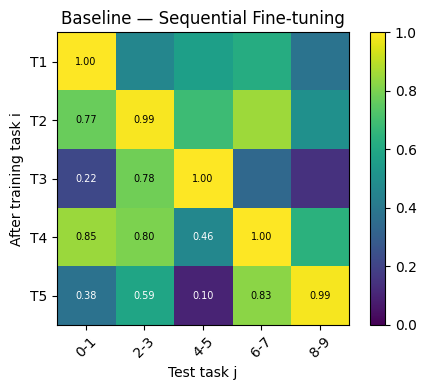

In [6]:
def plot_acc_matrix(A, title):
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(A, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Test task j')
    ax.set_ylabel('After training task i')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels([f'{a}-{b}' for a,b in TASKS], rotation=45)
    ax.set_yticklabels([f'T{i+1}' for i in range(5)])
    for ii in range(5):
        for jj in range(5):
            if ii >= jj:
                ax.text(jj, ii, f'{A[ii,jj]:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if A[ii,jj]<0.6 else 'black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

plot_acc_matrix(A_base, 'Baseline — Sequential Fine-tuning')


###  Exercise 2 — Forgetting Metric

In [7]:
# Q1: Which cell in A_base shows Task 1 accuracy after training all 5 tasks?
# (row index?, column index?) — answer in comment
# A: row=4, col=0
# Explanation: After training all 5 tasks, the last row corresponds to T5,
# and column 0 corresponds to Task 1.

# Q2: Compute forgetting vector F and average forgetting F_bar

def forgetting(A):
    max_acc_per_task = np.max(A, axis=0)
    final_acc_per_task = A[-1, :]
    F = max_acc_per_task - final_acc_per_task
    return F

F_base = forgetting(A_base)
print('Forgetting per task:', np.round(F_base,3))
print('Average forgetting: ', np.round(np.mean(F_base),3))

Forgetting per task: [0.622 0.405 0.9   0.172 0.   ]
Average forgetting:  0.42


## Part 4 — Method 1: Experience Replay

**Strategy:** keep a memory buffer of past samples. While training on task $i$,
mix current data with replay samples from memory.

### 4.1 — Implement MemoryBuffer


In [8]:
class MemoryBuffer:
    """Circular FIFO buffer storing (X, y) pairs."""

    def __init__(self, capacity=2000):
        self.capacity = capacity
        self.X = np.empty((0, 784), dtype=np.float32)
        self.y = np.empty((0,), dtype=np.int32)

    def add(self, X, y):
        """Add samples; drop oldest if over capacity."""
        # Concatenate new data
        self.X = np.vstack([self.X, X])
        self.y = np.hstack([self.y, y])
        # Keep only last `capacity` samples
        if len(self.y) > self.capacity:
            keep = len(self.y) - self.capacity
            self.X = self.X[keep:]
            self.y = self.y[keep:]

    def sample(self, batch_size):
        """Return a random batch from the buffer (or None if empty)."""
        if len(self.y) == 0:
            return None
        idx = np.random.choice(len(self.y), size=min(batch_size, len(self.y)), replace=False)
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.y)


# Quick test (should print: 100, then 100 because capacity=100)
buf = MemoryBuffer(capacity=100)
buf.add(np.zeros((80, 784), dtype=np.float32), np.zeros(80, dtype=np.int32))
buf.add(np.zeros((50, 784), dtype=np.float32), np.ones(50, dtype=np.int32))
print('Buffer size (expect 100):', len(buf))

Buffer size (expect 100): 100


### 4.2 — Training Loop with Replay

In [26]:
def run_replay(mem_capacity=2000, replay_batch=64, samples_per_task=400, epochs=2):
    model = build_mlp()
    # Compile so model.evaluate works
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    opt = keras.optimizers.Adam(1e-3)   # for manual gradient updates
    loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    buf = MemoryBuffer(capacity=mem_capacity)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):

        # ---- Training ----
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(128))

        for _ in range(epochs):
            for xb, yb in ds:
                replay = buf.sample(replay_batch)
                if replay is not None:
                    xm, ym = replay
                    xb = tf.concat([xb, tf.cast(xm, tf.float32)], axis=0)
                    yb = tf.concat([tf.reshape(yb, (-1,1)),
                                    tf.reshape(tf.cast(ym, tf.float32), (-1,1))], axis=0)
                else:
                    yb = tf.reshape(yb, (-1,1))

                # ---- Compute loss and apply gradient ----
                with tf.GradientTape() as tape:
                    preds = model(xb, training=True)
                    loss = loss_fn(yb, preds)
                grads = tape.gradient(loss, model.trainable_variables)
                opt.apply_gradients(zip(grads, model.trainable_variables))

        # ---- Add current task samples to buffer ----
        idx = np.random.choice(len(Xtr), size=min(samples_per_task, len(Xtr)), replace=False)
        buf.add(Xtr[idx], ytr[idx])

        # ---- Evaluate on all tasks ----
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

# Example usage:
replay_model, A_replay = run_replay()

After T1: [1.    0.455 0.562 0.624 0.359]
After T2: [0.995 0.989 0.684 0.804 0.573]
After T3: [0.981 0.974 0.998 0.553 0.175]
After T4: [0.976 0.94  0.958 0.995 0.578]
After T5: [0.956 0.954 0.877 0.982 0.985]


## Part 5 — Method 2: EWC (Elastic Weight Consolidation)

EWC adds a regularisation term that penalises changes to important weights.

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(\theta)
+ \frac{\lambda}{2}\sum_k F_k(\theta_k - \theta_k^{\text{old}})^2$$

### 5.1 — Diagonal Fisher Estimation


In [10]:
def fisher_diagonal(model, X, y, n_samples=1000):
    """
    Estimate diagonal Fisher information.
    F_k ≈ (1/N) Σ (∂ log p(y|x;θ) / ∂θ_k)^2
    """
    n = min(n_samples, len(X))
    idx = np.random.choice(len(X), size=n, replace=False)
    Xs = tf.constant(X[idx], dtype=tf.float32)
    ys = tf.constant(y[idx].reshape(-1,1), dtype=tf.float32)

    # Accumulator (one tensor per variable, same shape)
    F = [tf.zeros_like(v) for v in model.trainable_variables]
    loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    for i in range(n):
        xi = Xs[i:i+1]
        yi = ys[i:i+1]
        with tf.GradientTape() as tape:
            # Forward pass
            pred = model(xi, training=False)
            # log-likelihood = -loss
            log_lik = -loss_fn(yi, pred)

        # Gradients of log-likelihood w.r.t. model parameters
        grads = tape.gradient(log_lik, model.trainable_variables)
        F = [f + tf.square(g) for f, g in zip(F, grads)]

    # Average over all samples
    F = [f / tf.cast(n, tf.float32) for f in F]
    return F

### 5.2 — EWCTrainer class

In [11]:
class EWCTrainer:
    def __init__(self, model, lam=100.0):
        self.model     = model
        self.lam       = lam
        self.theta_old = None   # list of tf.Tensor (frozen copy of weights)
        self.F         = None   # list of tf.Tensor (Fisher diagonal)
        self.opt       = keras.optimizers.Adam(1e-3)
        self.loss_fn   = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    # ------------------------------------------------------------------
    def ewc_penalty(self):
        """Return scalar EWC regularisation term."""
        if self.theta_old is None:
            return tf.constant(0.0)
        penalty = 0.0
        for v, v_old, f in zip(self.model.trainable_variables,
                               self.theta_old, self.F):
            penalty += 0.5 * self.lam * tf.reduce_sum(f * tf.square(v - v_old))
        return penalty

    # ------------------------------------------------------------------
    def train_task(self, Xtr, ytr, epochs=2, batch_size=128):
        """Custom training loop with EWC penalty."""
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(batch_size))

        for _ in range(epochs):
            for xb, yb in ds:
                yb = tf.cast(tf.reshape(yb,(-1,1)), tf.float32)
                with tf.GradientTape() as tape:
                    pred = self.model(xb, training=True)
                    task_loss = self.loss_fn(yb, pred)
                    loss = task_loss + self.ewc_penalty()   # total loss
                grads = tape.gradient(loss, self.model.trainable_variables)
                self.opt.apply_gradients(
                    zip(grads, self.model.trainable_variables))

    # ------------------------------------------------------------------
    def consolidate(self, X, y):
        """Save θ_old and compute Fisher after finishing a task."""
        # Save a frozen copy of weights
        self.theta_old = [tf.identity(v) for v in self.model.trainable_variables]
        # Compute Fisher diagonal
        self.F = fisher_diagonal(self.model, X, y)

### 5.3 — Run EWC

In [12]:
def run_ewc(lam=100.0, epochs=2):
    model   = build_mlp()
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    trainer = EWCTrainer(model, lam=lam)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):
        trainer.train_task(Xtr, ytr, epochs=epochs)
        trainer.consolidate(Xtr, ytr)

        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

ewc_model, A_ewc = run_ewc(lam=100.0)   # uncomment after implementing


After T1: [1.    0.466 0.555 0.624 0.365]
After T2: [0.76  0.993 0.684 0.751 0.542]
After T3: [0.057 0.89  0.997 0.39  0.196]
After T4: [0.766 0.843 0.514 0.996 0.628]
After T5: [0.289 0.643 0.129 0.817 0.988]


### 🎓 Exercise 3 — EWC Hyperparameter Analysis

In [13]:
# Q1: What happens when λ is very small (e.g. 0.01)?
#     What about very large (e.g. 100000)?
# YOUR ANSWER:
# - Very small λ (0.01): The EWC penalty is weak, so the model behaves almost like
#   normal fine-tuning. Catastrophic forgetting is not prevented effectively.
# - Very large λ (100000): The EWC penalty dominates the loss, so the model is
#   extremely constrained to old weights. This can prevent learning the new task
#   properly, leading to underfitting on the current task.

# Q2: Why might EWC fail when tasks require very different feature representations?
# YOUR ANSWER:
# - EWC assumes that important weights for old tasks can stay fixed while new tasks
#   are learned. If tasks require very different features, many weights must change
#   to learn the new task. EWC’s penalty then conflicts with learning, so the model
#   cannot achieve good performance on both tasks simultaneously.

## Part 6 — Compare All Methods

Run all three methods, compute forgetting, and compare.


After T1: [0.999 0.425 0.544 0.607 0.413]
After T2: [0.78  0.992 0.7   0.856 0.5  ]
After T3: [0.145 0.794 0.998 0.371 0.135]
After T4: [0.809 0.816 0.478 0.998 0.626]
After T5: [0.362 0.594 0.106 0.84  0.988]
After T1: [1.    0.498 0.586 0.629 0.354]
After T2: [0.994 0.989 0.678 0.798 0.546]
After T3: [0.986 0.981 0.996 0.492 0.196]
After T4: [0.977 0.964 0.962 0.995 0.617]
After T5: [0.97  0.955 0.893 0.978 0.989]
After T1: [1.    0.463 0.538 0.637 0.372]
After T2: [0.751 0.992 0.677 0.809 0.56 ]
After T3: [0.07  0.88  0.998 0.371 0.232]
After T4: [0.81  0.856 0.537 0.997 0.626]
After T5: [0.216 0.643 0.123 0.832 0.99 ]
Avg forgetting  Baseline : 0.4170
Avg forgetting  Replay   : 0.0366
Avg forgetting  EWC      : 0.4344


/tmp/ipykernel_3699/295906279.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


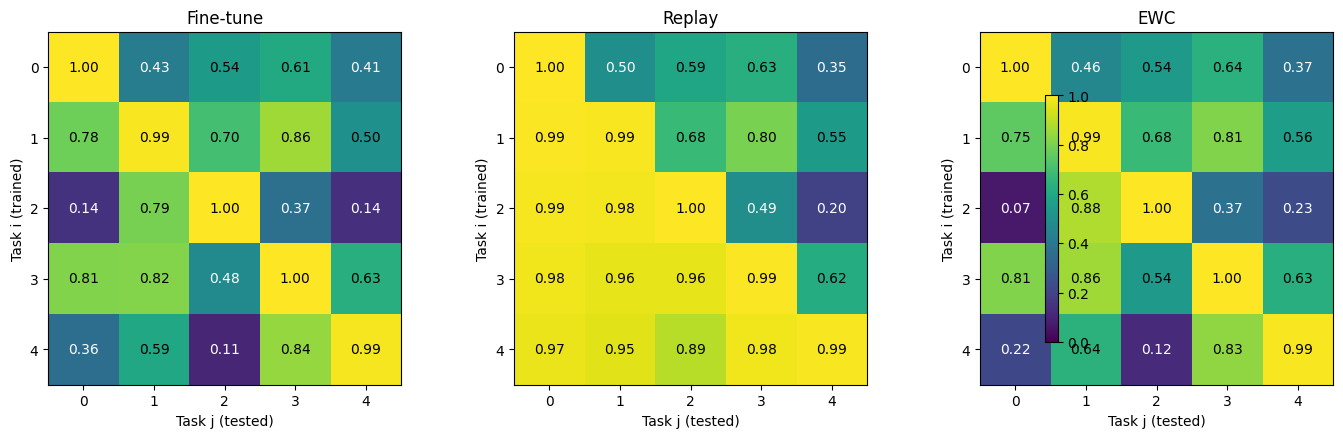

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Run all three methods
# -----------------------------
baseline_model, A_base   = run_finetune(epochs=2)
replay_model,   A_replay = run_replay(mem_capacity=2000, epochs=2)
ewc_model,      A_ewc    = run_ewc(lam=100.0, epochs=2)

# -----------------------------
# Compute forgetting per method
# -----------------------------
def forgetting(A):
    """Compute forgetting vector F_j = max_i A[i,j] - A[-1,j]"""
    max_acc_per_task = np.max(A, axis=0)
    final_acc_per_task = A[-1, :]
    return max_acc_per_task - final_acc_per_task

F_base   = forgetting(A_base)
F_replay = forgetting(A_replay)
F_ewc    = forgetting(A_ewc)

print(f'Avg forgetting  Baseline : {np.mean(F_base):.4f}')
print(f'Avg forgetting  Replay   : {np.mean(F_replay):.4f}')
print(f'Avg forgetting  EWC      : {np.mean(F_ewc):.4f}')

# -----------------------------
# Plot accuracy matrices side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, A, title in zip(axes,
                        [A_base, A_replay, A_ewc],
                        ['Fine-tune', 'Replay', 'EWC']):
    im = ax.imshow(A, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Task j (tested)')
    ax.set_ylabel('Task i (trained)')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center', color='white' if A[i,j]<0.5 else 'black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

## Challenges

### Challenge 1 — Balanced Replay Memory
Maintain exactly `capacity // n_tasks` samples per task class (not FIFO).

### Challenge 2 — Reservoir Sampling Buffer

Implement **Reservoir Sampling** for the replay buffer in order to maintain a **uniform sample of the entire data stream**.

Instead of storing the most recent samples (FIFO), the buffer should ensure that **every sample observed so far has the same probability of being stored in memory**.

#### Algorithm

For each new sample observed:

1. If the buffer is **not full**, simply add the sample.
2. Otherwise:
   - Draw a random integer  
     $$
     j \sim U(0, n_{\text{seen}} - 1)
     $$
   - If  
     $$
     j < \text{capacity}
     $$
     replace the element at position `j` in the buffer with the new sample.

This guarantees that each sample seen in the stream has probability:

$$
P(\text{stored}) = \frac{\text{capacity}}{n_{\text{seen}}}
$$

#### Goal

Modify the replay buffer to use **Reservoir Sampling** and compare the results with the standard **FIFO replay memory**.

Evaluate the impact on:
- final task accuracy
- average forgetting
- stability across tasks

### Challenge 3 — Online EWC
Accumulate Fisher across all past tasks:
$F_k^{(i)} = F_k^{(i-1)} + F_k^{\text{task } i}$

### Challenge 4 — Effect of Memory Size
Sweep `mem_capacity` over [100, 500, 1000, 2000, 5000] and plot
average forgetting vs memory size.

**Code Challenge 1**

In [15]:
class BalancedMemoryBuffer:
    """Replay buffer with equal memory per task."""

    def __init__(self, capacity=2000, n_tasks=5):
        self.capacity = capacity
        self.n_tasks = n_tasks
        self.per_task = capacity // n_tasks

        # store data per task
        self.data = {t: ([], []) for t in range(n_tasks)}

    def add(self, X, y, task_id):
        """Add samples for a specific task."""
        X_list, y_list = self.data[task_id]

        for xi, yi in zip(X, y):
            X_list.append(xi)
            y_list.append(yi)

        # keep only the most recent per_task samples
        if len(X_list) > self.per_task:
            X_list[:] = X_list[-self.per_task:]
            y_list[:] = y_list[-self.per_task:]

    def sample(self, batch_size):
        """Sample uniformly from all stored tasks."""
        X_all = []
        y_all = []

        for t in self.data:
            X_list, y_list = self.data[t]
            X_all.extend(X_list)
            y_all.extend(y_list)

        if len(X_all) == 0:
            return None

        X_all = np.array(X_all, dtype=np.float32)
        y_all = np.array(y_all, dtype=np.int32)

        idx = np.random.choice(len(X_all),
                               size=min(batch_size, len(X_all)),
                               replace=False)

        return X_all[idx], y_all[idx]

    def __len__(self):
        total = 0
        for t in self.data:
            total += len(self.data[t][0])
        return total

In [16]:
def run_replay2(mem_capacity=2000, replay_batch=64, samples_per_task=400, epochs=2):
    model = build_mlp()
    # Compile so model.evaluate works
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    opt = keras.optimizers.Adam(1e-3)   # for manual gradient updates
    loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    buf = BalancedMemoryBuffer(capacity=mem_capacity, n_tasks=5)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):

        # ---- Training ----
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(128))

        for _ in range(epochs):
            for xb, yb in ds:
                replay = buf.sample(replay_batch)
                if replay is not None:
                    xm, ym = replay
                    xb = tf.concat([xb, tf.cast(xm, tf.float32)], axis=0)
                    yb = tf.concat([tf.reshape(yb, (-1,1)),
                                    tf.reshape(tf.cast(ym, tf.float32), (-1,1))], axis=0)
                else:
                    yb = tf.reshape(yb, (-1,1))

                # ---- Compute loss and apply gradient ----
                with tf.GradientTape() as tape:
                    preds = model(xb, training=True)
                    loss = loss_fn(yb, preds)
                grads = tape.gradient(loss, model.trainable_variables)
                opt.apply_gradients(zip(grads, model.trainable_variables))

        # ---- Add current task samples to buffer ----
        idx = np.random.choice(len(Xtr), size=min(samples_per_task, len(Xtr)), replace=False)
        buf.add(Xtr[idx], ytr[idx], task_id=i)

        # ---- Evaluate on all tasks ----
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

# Example usage:
replay_model, A_replay = run_replay2()

After T1: [1.    0.491 0.558 0.664 0.361]
After T2: [0.993 0.992 0.625 0.809 0.577]
After T3: [0.982 0.968 0.998 0.484 0.22 ]
After T4: [0.971 0.954 0.954 0.995 0.66 ]
After T5: [0.953 0.96  0.874 0.979 0.983]


**Code challenge 2**

In [19]:
class ReservoirBuffer:
    """Replay buffer using Reservoir Sampling."""

    def __init__(self, capacity=2000):
        self.capacity = capacity
        self.X = np.empty((capacity, 784), dtype=np.float32)
        self.y = np.empty((capacity,), dtype=np.int32)

        self.n_seen = 0     # total samples observed
        self.size = 0       # current buffer size

    def add(self, X, y):
        """Add a batch of samples using reservoir sampling."""
        for xi, yi in zip(X, y):

            if self.size < self.capacity:
                # Buffer not full → just add
                self.X[self.size] = xi
                self.y[self.size] = yi
                self.size += 1

            else:
                # Reservoir replacement
                j = np.random.randint(0, self.n_seen + 1)

                if j < self.capacity:
                    self.X[j] = xi
                    self.y[j] = yi

            self.n_seen += 1

    def sample(self, batch_size):
        """Sample random batch from buffer."""
        if self.size == 0:
            return None

        idx = np.random.choice(self.size,
                               size=min(batch_size, self.size),
                               replace=False)

        return self.X[idx], self.y[idx]

    def __len__(self):
        return self.size

In [20]:
def run_replay3(mem_capacity=2000, replay_batch=64, samples_per_task=400, epochs=2):
    model = build_mlp()
    # Compile so model.evaluate works
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    opt = keras.optimizers.Adam(1e-3)   # for manual gradient updates
    loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)
    buf = ReservoirBuffer(capacity=mem_capacity)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):

        # ---- Training ----
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(128))

        for _ in range(epochs):
            for xb, yb in ds:
                replay = buf.sample(replay_batch)
                if replay is not None:
                    xm, ym = replay
                    xb = tf.concat([xb, tf.cast(xm, tf.float32)], axis=0)
                    yb = tf.concat([tf.reshape(yb, (-1,1)),
                                    tf.reshape(tf.cast(ym, tf.float32), (-1,1))], axis=0)
                else:
                    yb = tf.reshape(yb, (-1,1))

                # ---- Compute loss and apply gradient ----
                with tf.GradientTape() as tape:
                    preds = model(xb, training=True)
                    loss = loss_fn(yb, preds)
                grads = tape.gradient(loss, model.trainable_variables)
                opt.apply_gradients(zip(grads, model.trainable_variables))

        # ---- Add current task samples to buffer ----
        idx = np.random.choice(len(Xtr), size=min(samples_per_task, len(Xtr)), replace=False)
        buf.add(Xtr[idx], ytr[idx])

        # ---- Evaluate on all tasks ----
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

# Example usage:
replay_model, A_replay = run_replay3()

After T1: [1.    0.466 0.561 0.641 0.385]
After T2: [0.992 0.99  0.649 0.758 0.585]
After T3: [0.984 0.976 0.997 0.567 0.196]
After T4: [0.975 0.964 0.953 0.994 0.633]
After T5: [0.951 0.97  0.91  0.974 0.984]


**Code challenge 3**

In [24]:
class EWCTrainer2:
    def __init__(self, model, lam=100.0):
        self.model     = model
        self.lam       = lam
        self.theta_old = None   # list of tf.Tensor (frozen copy of weights)
        self.F         = None   # list of tf.Tensor (Fisher diagonal)
        self.opt       = keras.optimizers.Adam(1e-3)
        self.loss_fn   = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    # ------------------------------------------------------------------
    def ewc_penalty(self):
        """Return scalar EWC regularisation term."""
        if self.theta_old is None:
            return tf.constant(0.0)
        penalty = 0.0
        for v, v_old, f in zip(self.model.trainable_variables,
                               self.theta_old, self.F):
            penalty += 0.5 * self.lam * tf.reduce_sum(f * tf.square(v - v_old))
        return penalty

    # ------------------------------------------------------------------
    def train_task(self, Xtr, ytr, epochs=2, batch_size=128):
        """Custom training loop with EWC penalty."""
        ds = (tf.data.Dataset
              .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
              .shuffle(10_000, seed=SEED)
              .batch(batch_size))

        for _ in range(epochs):
            for xb, yb in ds:
                yb = tf.cast(tf.reshape(yb,(-1,1)), tf.float32)
                with tf.GradientTape() as tape:
                    pred = self.model(xb, training=True)
                    task_loss = self.loss_fn(yb, pred)
                    loss = task_loss + self.ewc_penalty()   # total loss
                grads = tape.gradient(loss, self.model.trainable_variables)
                self.opt.apply_gradients(
                    zip(grads, self.model.trainable_variables))

    # ------------------------------------------------------------------
    def consolidate2(self, X, y):
    # compute Fisher for current task
      F_new = fisher_diagonal(self.model, X, y)

      if self.F is None:
        # first task
        self.F = F_new
      else:
        # accumulate Fisher
        self.F = [f_old + f_new
                  for f_old, f_new in zip(self.F, F_new)]

    # save current weights
      self.theta_old = [tf.identity(v) for v in self.model.trainable_variables]



In [25]:
def run_ewc2(lam=100.0, epochs=2):
    model   = build_mlp()
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    trainer = EWCTrainer2(model, lam=lam)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):
        trainer.train_task(Xtr, ytr, epochs=epochs)
        trainer.consolidate2(Xtr, ytr)

        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

ewc_model, A_ewc = run_ewc2(lam=100.0)   # uncomment after implementing


After T1: [1.    0.475 0.59  0.64  0.357]
After T2: [0.722 0.995 0.708 0.715 0.526]
After T3: [0.05  0.868 0.997 0.366 0.174]
After T4: [0.711 0.882 0.546 0.997 0.625]
After T5: [0.278 0.704 0.134 0.879 0.992]


**Code challenge 4**

In [28]:
def forgetting_fn(A):
    max_acc = np.max(A, axis=0)
    final_acc = A[-1]
    return max_acc - final_acc


mem_sizes = [100, 500, 1000, 2000, 5000]
forgetting_vals = []

for m in mem_sizes:
    print(f"\nRunning Replay with memory size = {m}")

    model, A = run_replay(mem_capacity=m, epochs=2)

    F = forgetting_fn(A)
    avg_F = np.mean(F)

    forgetting_vals.append(avg_F)

    print(f"Average forgetting: {avg_F:.4f}")


Running Replay with memory size = 100
After T1: [1.    0.452 0.552 0.631 0.395]
After T2: [0.988 0.991 0.688 0.796 0.568]
After T3: [0.193 0.951 0.996 0.364 0.249]
After T4: [0.698 0.839 0.9   0.996 0.589]
After T5: [0.392 0.631 0.131 0.961 0.987]
Average forgetting: 0.3734

Running Replay with memory size = 500
After T1: [1.    0.464 0.547 0.622 0.378]
After T2: [0.993 0.989 0.662 0.836 0.591]
After T3: [0.945 0.978 0.998 0.421 0.242]
After T4: [0.839 0.907 0.964 0.996 0.605]
After T5: [0.536 0.832 0.807 0.978 0.989]
Average forgetting: 0.1657

Running Replay with memory size = 1000
After T1: [1.    0.481 0.566 0.65  0.373]
After T2: [0.994 0.987 0.656 0.808 0.547]
After T3: [0.98  0.972 0.998 0.492 0.209]
After T4: [0.955 0.944 0.963 0.994 0.649]
After T5: [0.6   0.953 0.897 0.97  0.987]
Average forgetting: 0.1117

Running Replay with memory size = 2000
After T1: [1.    0.461 0.574 0.626 0.358]
After T2: [0.992 0.99  0.663 0.82  0.578]
After T3: [0.983 0.974 0.998 0.514 0.238]
After

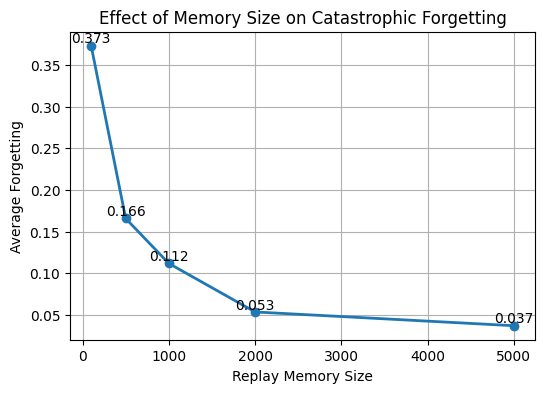

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(mem_sizes, forgetting_vals, marker='o', linewidth=2)

plt.xlabel("Replay Memory Size")
plt.ylabel("Average Forgetting")
plt.title("Effect of Memory Size on Catastrophic Forgetting")

plt.grid(True)

for x, y in zip(mem_sizes, forgetting_vals):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.show()

## Optional- Continual Learning with framework
Instead of implementing the methods from scratch, several research frameworks provide ready-to-use implementations of continual learning algorithms:

- **Avalanche** (https://avalanche.continualai.org)  
  Supports Replay, Reservoir Sampling, EWC, GEM, and many benchmarks.

- **Continuum** (https://github.com/Continvvm/continuum)  
  Lightweight toolkit for continual datasets and rehearsal buffers.

These frameworks are widely used in research and can greatly simplify experimentation with continual learning methods.
In this section we reproduce the main methods studied in this lab using the **Avalanche Continual Learning framework**.

Avalanche provides ready-to-use implementations of many continual learning strategies, allowing us to focus on experimentation rather than implementing algorithms from scratch.

We compare three methods:

- **Naive Fine-tuning (Baseline)**  
  The model is trained sequentially on tasks without any mechanism to prevent forgetting.

- **Replay (Experience Replay)**  
  A memory buffer stores samples from past tasks and replays them during training.

- **Elastic Weight Consolidation (EWC)**  
  Important parameters for previous tasks are protected using Fisher Information.

Avalanche automatically handles:
- task streams
- evaluation metrics
- replay buffers
- continual learning strategies

In [38]:
# =========================================================
# 1 — Install Avalanche
# =========================================================
# Avalanche is a popular research framework for Continual Learning.
# It provides implementations of many CL strategies such as Replay, EWC, GEM, etc.

!pip install avalanche-lib
# =========================================================
# 2 — Imports
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim

from avalanche.benchmarks.classic import SplitMNIST
from avalanche.models import SimpleMLP
from avalanche.training.supervised import Naive, Replay, EWC
from avalanche.training.plugins import EvaluationPlugin
from avalanche.evaluation.metrics import accuracy_metrics, forgetting_metrics
from avalanche.logging import InteractiveLogger
# =========================================================
# 3 — Create a Continual Learning Benchmark
# =========================================================
# We use SplitMNIST, a standard benchmark for continual learning.
# The dataset is split into 5 sequential tasks:
# T1: (0,1)  T2: (2,3)  T3: (4,5)  T4: (6,7)  T5: (8,9)

benchmark = SplitMNIST(
    n_experiences=5,
    seed=1,
    return_task_id=False
)
# =========================================================
# 4 — Model
# =========================================================
# Simple feedforward neural network used in all methods.

model = SimpleMLP(
    num_classes=10,
    input_size=28*28,
    hidden_size=256
)
# =========================================================
# 5 — Optimizer and Loss
# =========================================================
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
# 6 — One plugin per strategy
def make_plugin():
    return EvaluationPlugin(
        accuracy_metrics(epoch=True, experience=True),
        forgetting_metrics(experience=True),
        loggers=[InteractiveLogger()]
    )

# 7 — Naive
naive_strategy = Naive(
    model, optimizer, criterion,
    train_mb_size=128, train_epochs=1, eval_mb_size=128,
    evaluator=make_plugin()
)

# 8 — Replay
replay_strategy = Replay(
    model, optimizer, criterion,
    mem_size=2000,
    train_mb_size=128, train_epochs=1, eval_mb_size=128,
    evaluator=make_plugin()
)

# 9 — EWC
ewc_strategy = EWC(
    model, optimizer, criterion,
    ewc_lambda=100,
    train_mb_size=128, train_epochs=1, eval_mb_size=128,
    evaluator=make_plugin()
)
# =========================================================
# 10 — Training Loop (Naive Fine-tuning)
# =========================================================
print("Starting Naive training...")

for experience in benchmark.train_stream:

    print("Training on task:", experience.current_experience)

    naive_strategy.train(experience)
    naive_strategy.eval(benchmark.test_stream)
# =========================================================
# 11 — Training Loop (Replay)
# =========================================================
print("Starting Replay training...")
for experience in benchmark.train_stream:
    print("Training Replay on task:", experience.current_experience)

    replay_strategy.train(experience)
    replay_strategy.eval(benchmark.test_stream)
# =========================================================
# 12 — Training Loop (EWC)
# =========================================================

print("Starting EWC training...")

for experience in benchmark.train_stream:

    print("Training EWC on task:", experience.current_experience)

    ewc_strategy.train(experience)
    ewc_strategy.eval(benchmark.test_stream)

/usr/local/lib/python3.12/dist-packages/avalanche/training/templates/base.py:468: PositionalArgumentsDeprecatedWarning: Avalanche is transitioning to strategy constructors that accept named (keyword) arguments only. This is done to ensure that there is no confusion regarding the meaning of each argument (strategies can have many arguments). Your are passing 3 positional arguments to the Naive.__init__ method. Consider passing them as names arguments. The ability to pass positional arguments will be removed in the future.
  warnings.warn(error_str, category=PositionalArgumentsDeprecatedWarning)
/usr/local/lib/python3.12/dist-packages/avalanche/training/templates/base.py:468: PositionalArgumentsDeprecatedWarning: Avalanche is transitioning to strategy constructors that accept named (keyword) arguments only. This is done to ensure that there is no confusion regarding the meaning of each argument (strategies can have many arguments). Your are passing 3 positional arguments to the Replay.__

Starting Naive training...
Training on task: 0
-- >> Start of training phase << --
100%|██████████| 89/89 [00:02<00:00, 39.04it/s]
Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9549
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 46.60it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.9800
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 43.60it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 47.74it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.0000
-- Starting eval on experience 3 (Task 0) from te

/usr/local/lib/python3.12/dist-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 46.43it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.9832
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 45.90it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 47.63it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.0000
-- Starting eval on experience 3 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 45.89it/s]
> Eval on experience 3 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 = 0.0000
-- Starting eval on experi

/usr/local/lib/python3.12/dist-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

100%|██████████| 15/15 [00:00<00:00, 48.63it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.0859
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8973
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 45.24it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0415
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.9349
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 47.41it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 = 0.1059
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.8685
-- Starting eval on experience 3 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 47.39it/s]
> Eval on experience 3 (Task 0) from test stream ended.
	Top1_Ac

/usr/local/lib/python3.12/dist-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8322
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
 53%|█████▎    | 8/15 [00:00<00:00, 46.45it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


100%|██████████| 15/15 [00:00<00:00, 45.08it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.0849
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8984
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 43.59it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0411
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.9354
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 47.02it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 = 0.0742
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.9002
-- Starting eval on experience 3 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 45.76it/s]
> Eval on experience 3 (Task 0) from test stream ended.
	Experie

Naive  acc per task: [0.0, 0.0, 0.0005117707267144319, 0.05002476473501734, 0.982089552238806]
Replay acc per task: [0.8983783783783784, 0.9353945546838948, 0.9002047082906858, 0.8172362555720654, 0.9597014925373134]
EWC    acc per task: [0.23891891891891892, 0.37978772496538993, 0.33469805527123847, 0.3645368994551758, 0.9875621890547264]


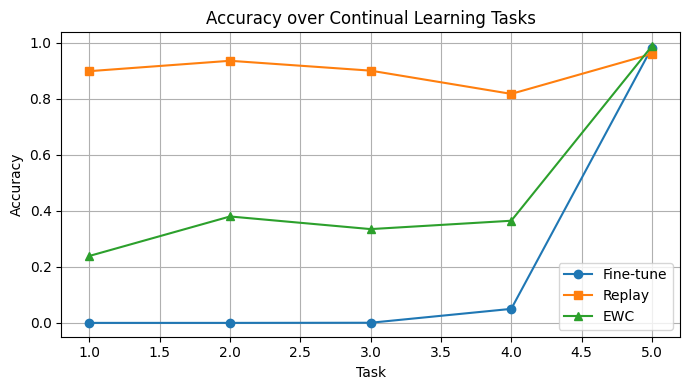

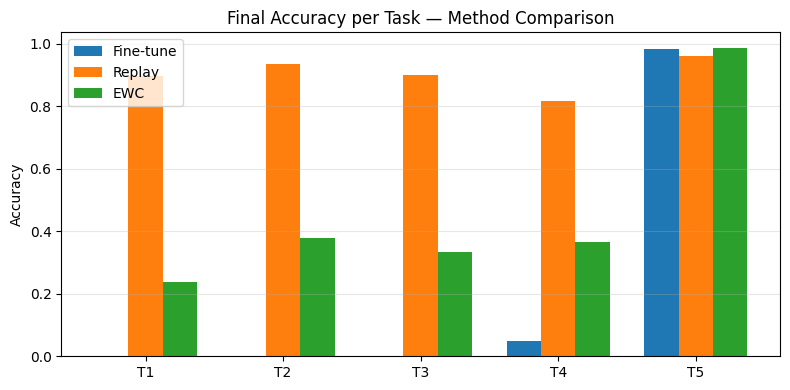

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


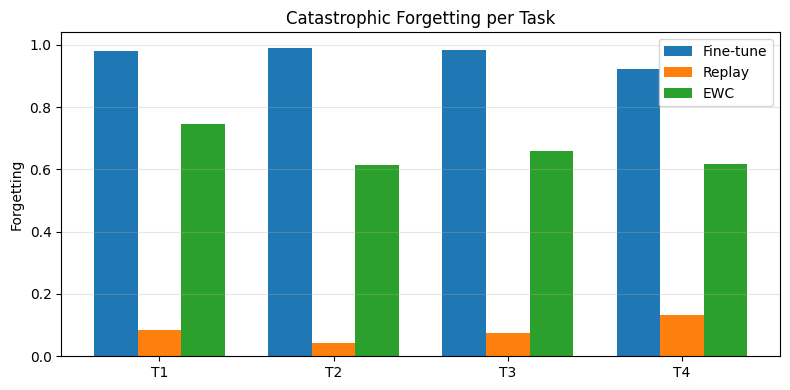

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [42]:
import re
import numpy as np
import matplotlib.pyplot as plt

def collect_acc_per_experience(plugin):
    results = plugin.get_last_metrics()
    acc = {}
    for k, v in results.items():
        if "Top1_Acc_Exp" in k:
            # key ends with /Exp000, /Exp001, etc.
            match = re.search(r'/Exp(\d+)$', k)
            if match:
                exp_id = int(match.group(1))
                acc[exp_id] = v
    return [acc[i] for i in sorted(acc.keys())]

def collect_forgetting(plugin):
    results = plugin.get_last_metrics()
    forg = {}
    for k, v in results.items():
        if "ExperienceForgetting" in k:
            match = re.search(r'/Exp(\d+)$', k)
            if match:
                exp_id = int(match.group(1))
                forg[exp_id] = v
    return [forg[i] for i in sorted(forg.keys())] if forg else None

# Collect results
acc_finetune = collect_acc_per_experience(naive_strategy.evaluator)
acc_replay   = collect_acc_per_experience(replay_strategy.evaluator)
acc_ewc      = collect_acc_per_experience(ewc_strategy.evaluator)

print("Naive  acc per task:", acc_finetune)
print("Replay acc per task:", acc_replay)
print("EWC    acc per task:", acc_ewc)

# ── Plot 1: Line chart ──────────────────────────────────────
exp_ids = list(range(1, len(acc_finetune) + 1))

plt.figure(figsize=(7, 4))
plt.plot(exp_ids, acc_finetune, marker='o', label="Fine-tune")
plt.plot(exp_ids, acc_replay,   marker='s', label="Replay")
plt.plot(exp_ids, acc_ewc,      marker='^', label="EWC")
plt.title("Accuracy over Continual Learning Tasks")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Plot 2: Grouped bar chart ───────────────────────────────
x = np.arange(len(acc_finetune))
w = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x - w, acc_finetune, width=w, label="Fine-tune")
plt.bar(x,     acc_replay,   width=w, label="Replay")
plt.bar(x + w, acc_ewc,      width=w, label="EWC")
plt.xticks(x, [f"T{i+1}" for i in range(len(x))])
plt.ylabel("Accuracy")
plt.title("Final Accuracy per Task — Method Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 3: Forgetting bar chart ────────────────────────────
forg_finetune = collect_forgetting(naive_strategy.evaluator)
forg_replay   = collect_forgetting(replay_strategy.evaluator)
forg_ewc      = collect_forgetting(ewc_strategy.evaluator)

if forg_finetune:
    x = np.arange(len(forg_finetune))
    plt.figure(figsize=(8, 4))
    plt.bar(x - w, forg_finetune, width=w, label="Fine-tune")
    plt.bar(x,     forg_replay,   width=w, label="Replay")
    plt.bar(x + w, forg_ewc,      width=w, label="EWC")
    plt.xticks(x, [f"T{i+1}" for i in range(len(x))])
    plt.ylabel("Forgetting")
    plt.title("Catastrophic Forgetting per Task")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Advantages of Using Avalanche

Avalanche provides:

- ready-to-use continual learning algorithms
- evaluation metrics
- benchmark datasets
- replay buffers
- logging and visualization

This allows researchers to focus on **experiments rather than implementation**.